# Global Kernel k-Means 

This is the implementation of The Global Kernel k-Means Algorithm for Clustering in Feature Space

Dataset : "2D Clustering Dataset Collection" https://www.kaggle.com/datasets/samoilovmikhail/2d-clustering-dataset-collection?select=file_6.csv

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### Gaussian Kernel Function

In [8]:
#Transform the datapoints to NxN Kernel matrix
def gaussian_kernel(X, sigma):
    #Sum of squares of X
    X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
    dist_sq = X_sq + X_sq.T - 2 * X @ X.T
    #Gaussian Kernal - convert distance to similarities 
    K = np.exp(-dist_sq / (2 * sigma**2))
    return K

### Algorithm 1 : Kernel k-Means

In [9]:
#Calculate the distance in feature space
def distance(K, n, c):
    m = len(c)
    if m == 0:
        return np.inf
    c = np.asarray(c, dtype=int)
    first = K[n, n]
    second = (2.0 / m) * K[n, c].sum()
    third = (1.0 / (m * m)) * K[np.ix_(c, c)].sum()
    return first - second + third

#Clustering error after convergence
def clustering_error(K, C):
    E = 0.0
    for i in range(len(C)):
        for n in C[i]:
            E += distance(K, n, C[i])
    return float(E)
    
 #Algorithm 1 from the paper   
def kernel_kmeans(K, k, C, max_epochs=100):  
    C = [list(ci) for ci in C]
    N = K.shape[0]
    C_prev = None
    for t in range(max_epochs):
        c_hat = [[] for _ in range(k)]
        for n in range(N):
            d = [] 
            for i in range(k):
                #For each point, calculate the distance from the point to the cluster 
                d.append(distance(K, n, C[i]))
            best_k = int(np.argmin(d))
            #Assign the point to the cluster with the minimum distance
            c_hat[best_k].append(n)
        C = c_hat
        if C_prev is not None and C_prev == c_hat:
            break # for t
        C_prev = [l.copy() for l in c_hat]
    #Calculate the clustering error for the converged cluster    
    c_error = clustering_error(K, C)
    return t, C, c_error     

### Algorithm 2 - Global Kernel K-Means

In [20]:
def global_kernel_kmeans(K, k):
    N = K.shape[0]
    #1 clustering problem
    clusters = [list(range(N))]

    for i in range(2, k + 1):
        best_ce = np.inf
        best_cluster = None
        for n in range(N):
            init = [ci.copy() for ci in clusters]
            #Add datapoint n as kth cluster
            init.append([n])
            for xn in init[:-1]:
                if n in xn:
                    #remove the datapoint n from previous clusters
                    xn.remove(n)
                    break
            #Run kernel k-means with every point 
            _,c, ce = kernel_kmeans(K, i, init)
            #Keep the cluster with the lowest error as the best_cluster
            if ce < best_ce:
                best_ce, best_cluster = ce, c
        #Update the clusters
        clusters = best_cluster
    return best_cluster

In [31]:
def kmeans(X, c, max_epochs=100, verbose=False):
    c = c.copy() 
    M = X.shape[0]
    K = c.shape[0]
    for t in range(max_epochs):
        C = [[] for _ in range(K)]
        cost = 0
        for i in range(M):
            mindist = np.inf 
            for k in range(K):
                #Euclidean distance
                euclidean_dist = np.sqrt(np.sum((X[i,] - c[k,])**2))
                if euclidean_dist < mindist:
                    best_k = k
                    mindist = euclidean_dist
            cost += mindist**2
            #Add the datapoint to the cluster with minimum distance
            C[best_k].append(i)
        for k in range(K):
            c[k,] = np.mean(X[C[k],], axis=0)
        if verbose:
            print("t =", t, "assignments:\n", C, "\ncluster centres:\n", c)
        if t > 0 and C_prev == C: 
            break
        C_prev = [l.copy() for l in C] 
    return t, C, c, cost

In [48]:
def get_labels(X, C):
    labels = np.empty(X.shape[0], dtype=int)
    for k, cluster in enumerate(C):
        labels[cluster] = k
    return labels

def plot_results(X, C_kmeans, C_global):
    kmeans_labels = get_labels(X, C)
    gk_labels = get_labels(X, C_global)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 7)) 
    colors = ['red', 'blue'] 
    cmap = ListedColormap(colors)
    #Plot k-Means
    axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap=cmap, s=60, alpha=0.5, edgecolors='black')
    axes[0].set_title("Standard K-Means Clustering")

    #Plot Global Kernel k-Means
    axes[1].scatter(X[:, 0], X[:, 1], c=gk_labels, cmap=cmap, s=60, alpha=0.5, edgecolors='black')
    axes[1].set_title("Global Kernel K-Means Clustering")

    plt.tight_layout()
    plt.show()

In [49]:
def silhouette_score(X, labels):
    n = X.shape[0]
    labels = np.asarray(labels)
    u_labels = np.unique(labels)

    if u_labels.size < 2:
        return 0.0
    # Euclidean distances
    distances = np.sqrt(((X[:, None] - X) ** 2).sum(axis=2))
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        #Get all indices of the points belonging to ci except i
        cluster_i = np.where(labels == ci)[0]
        cluster_i = cluster_i[cluster_i != i]
        if cluster_i.size == 0:
            scores[i] = 0.0
            continue
        # mean distances within the same cluster 
        a = distances[i, cluster_i].mean()
        b = np.inf
        for cj in u_labels:
            if cj == ci:
                continue
            other_cluster = np.where(labels == cj)[0]
            #Smallest mean distance to other clusters
            b = min(b, distances[i, other_cluster].mean())
        scores[i] = (b - a) / max(a, b)
    return scores.mean()


The Global Kernel KMeans algorithm has high computational cost due to the O(N^3Mt) time complexity.

Running Global Kernel KMeans....

Silhouette Score : 0.14018609586222572


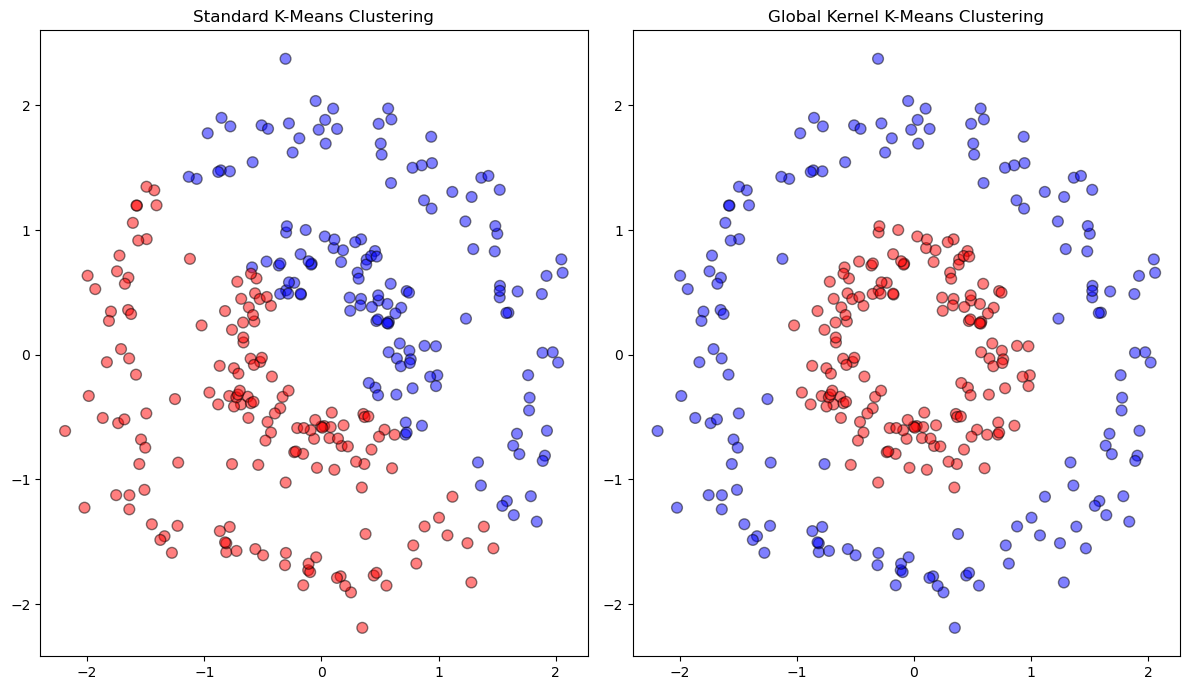

In [50]:
#Load data from csv file
df = pd.read_csv('file_6.csv')
#Take only the datapoints from the datafrane
df = df.iloc[:, :-1]
X = df.to_numpy() 
#Normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

#Transform from input space to feature space using a Gaussian kernel
K = gaussian_kernel(X , sigma =0.6)
      
#Global Kernel k-Means (Input : Kernel matrix K, no. of clusters | Output : Clusters)  

print("\nThe Global Kernel KMeans algorithm has high computational cost due to the O(N^3Mt) time complexity.")
print("\nRunning Global Kernel KMeans....")

C_global = global_kernel_kmeans(K, 2)

print("\nSilhouette Score : {s_score}".format(s_score = silhouette_score(X, gk_labels)))

#k-Means 
#Random cluster assignment
c = np.array([X[9], X[89]])
_,C_kmeans,_,_ = kmeans(X,c)

#Plotting all the results for comparison
plot_results(X,C_kmeans,C_global)

### Overview of tools used
ChatGPT (OpenAI) – Used for the understanding of mathematical formula involved in the algorithm and for clarification of questions on kernels. 

Kaggle - Source of dataset